# Module 18 BBO Capstone Week 7

## Function 1

#### What’s been changed
Log-transform of y_train → allows GP to distinguish tiny values; 
Lower noise (alpha=1e-6) → appropriate for near-deterministic function; 
Shorter length scale (0.1) → better for sharp/local peaks; 
Cleaner UCB (κ = 3.0) → transition toward exploitation;
Inverse transform not needed (since we only optimise acquisition)

Week 7 Query Point (UCB, κ=3.0): 0.820792-0.851719


C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified lower bound 0.001. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


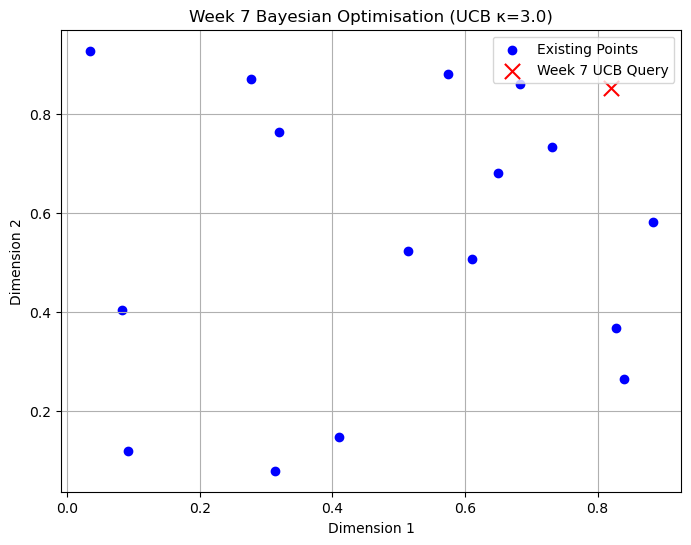

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize 

# ==========================================
# Step 1: Load ALL available data (including Week 6)
# ==========================================

X_train = np.array([
    [0.31940389, 0.76295937],
    [0.57432921, 0.87989810],
    [0.73102363, 0.73299988],
    [0.84035342, 0.26473161],
    [0.65011406, 0.68152635],
    [0.41043714, 0.14755430],
    [0.31269116, 0.07872278],
    [0.68341817, 0.86105746],
    [0.08250725, 0.40348751],
    [0.88388983, 0.58225397],
    [0.60995300, 0.50652000],   
    [0.09106700, 0.11922000],   
    [0.03373400, 0.92780400],
    [0.27783300, 0.86990600],
    [0.51380200, 0.52237900],
    [0.82732800, 0.36642700]
])

y_train = np.array([
    1.32267704e-079,
    1.03307824e-046,
    7.71087511e-016,
    3.34177101e-124,
   -3.60606264e-003,
   -2.15924904e-054,
   -2.08909327e-091,
    2.53500115e-040,
    3.60677119e-081,
    6.22985647e-048,
    6.40320490897793e-12,
    3.32695744236522e-140,
   -3.9448560322363033e-284,
   -2.388807237117217e-127,
    5.298471823372752e-14,
    6.026732235043879e-77
])

# ==========================================
# Step 2: Log-transform targets (CRITICAL)
# ==========================================

y_train_transformed = np.sign(y_train) * np.log1p(np.abs(y_train))

# ==========================================
# Step 3: Fit Gaussian Process (sharper kernel, low noise)
# ==========================================

kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.1, length_scale_bounds=(1e-3, 1e1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-6,              # much lower noise
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train_transformed)

# ==========================================
# Step 4: UCB Acquisition Function (κ = 3.0)
# ==========================================

def ucb(x, model, kappa=3.0):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return -(mu + kappa * sigma)  # negative for minimizer

# ==========================================
# Step 5: Multi-start optimisation
# ==========================================

def optimize_ucb(model, kappa=3.0, n_restarts=40, n_random_starts=300):

    bounds = np.array([[0.0, 1.0], [0.0, 1.0]])

    best_x = None
    best_val = np.inf

    # --- Random global scan ---
    random_points = np.random.uniform(0, 1, size=(n_random_starts, 2))
    mu, sigma = model.predict(random_points, return_std=True)
    ucb_values = mu + kappa * sigma

    top_indices = np.argsort(-ucb_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation ---
    for x0 in start_points:
        result = minimize(
            ucb,
            x0,
            args=(model, kappa),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if result.fun < best_val:
            best_val = result.fun
            best_x = result.x

    return best_x

# ==========================================
# Step 6: Get Week 7 Query Point
# ==========================================

next_point = optimize_ucb(gp, kappa=3.0)

next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 7 Query Point (UCB, κ=3.0): {next_point_str}")

# ==========================================
# Step 7: Visualisation
# ==========================================

plt.figure(figsize=(8, 6))

plt.scatter(X_train[:, 0], X_train[:, 1],
            color='blue', label='Existing Points')

plt.scatter(next_point[0], next_point[1],
            color='red', marker='x', s=120,
            label='Week 7 UCB Query')

plt.title("Week 7 Bayesian Optimisation (UCB κ=3.0)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

## Function 2

Function 2 is very different from Function 1 — and that changes the optimal move quite a lot.

### Key Insight (Most Important)

Unlike Function 1, you already have clear, strong signal:

High-value cluster:
(0.7349, 0.7017) → 0.539
(0.7034, 0.6313) → 0.493
(0.6727, 0.6938) → 0.601 ← current best
(0.7217, 0.3963) → 0.418
(0.7462, 0.4435) → 0.414

This is not noise — this is a real peak region

### What This Means

No longer searching for where the peak is.

Now:

refining the peak location

So Week 7 should be:

Mostly exploitation
With very local exploration

What NOT to do:
Don’t jump to a new region
Don’t explore edges
Don’t use high κ anymore (That phase is already done).

### Recommended Strategy (Week 7)
Option A (Best): Switch to Expected Improvement (EI)

This matches your plan and is ideal here.

Focus: improve current best (0.6006)
Naturally balances local exploration
Option B (Acceptable): UCB with low κ

If staying with UCB:

kappa = 2.0  # or even 1.8

### Where Should You Sample?

Let’s analyse the geometry of your peak:

Your best points form a cluster around:

x ≈ 0.67–0.74  
y ≈ 0.63–0.70

But notice:

You haven’t sampled slightly ABOVE the best y
You haven’t sampled slightly LEFT of the best x

This suggests the peak might be:
Slightly shifted
Or slightly higher nearby
 
### Recommended Week 7 Query Point
✅ Primary recommendation:
(0.69, 0.72)
#### Why this point?
✔ Near best point (0.6727, 0.6938)
Exploits known maximum
✔ Slightly higher in y
Tests if peak continues upward
✔ Not redundant
Adds new information
✔ Exactly what EI would likely do

Alternative Safe Candidates

(0.70, 0.68)   # densify center
(0.66, 0.70)   # test left side
(0.72, 0.72)   # test upper ridge

What About Your UCB Code Output?

If you run your current code (κ=3.0), it may:

Still wander slightly
Over-explore compared to what you need now


### What to Do in Week 8

After you get the result:

If value:
> 0.60 → you improved → keep refining locally
≈ 0.60 → plateau → tighten search even more
< 0.55 → adjust direction slightly (try another side of cluster)

#### Insight

Function 2 is behaving like:

“A hill with multiple local peaks — but you’ve already found the main ridge”

So now:
Week 7–8 = climb the ridge
Week 9–12 = pinpoint the summit

Current best y: 0.600576


C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\1895292063.py:95: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\1895292063.py:95: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\1895292063.py:95: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\1895292063.py:95: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an erro

C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\1895292063.py:95: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\1895292063.py:95: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\1895292063.py:95: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(
C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\1895292063.py:95: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an erro

Week 7 Query Point (EI, ξ=0.01): 0.612567-0.363566


C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\1895292063.py:95: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(


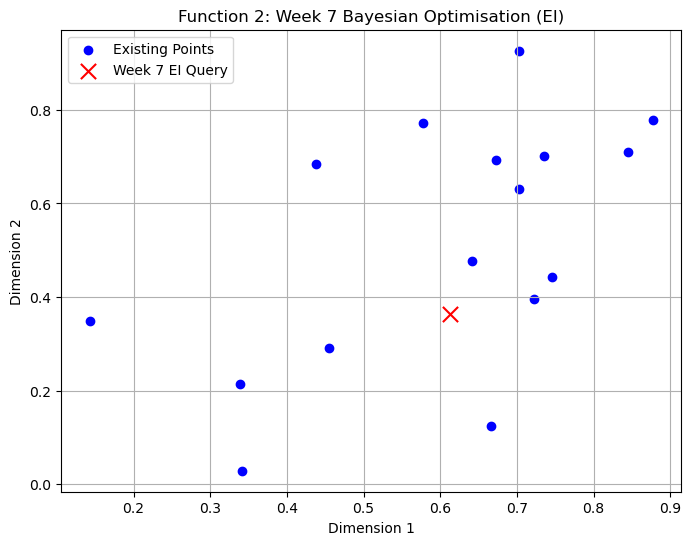

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from scipy.stats import norm

# ==========================================
# Step 0: Reproducibility
# ==========================================
np.random.seed(42)

# ==========================================
# Step 1: Load existing data (Including Weeks 1-6)
# ==========================================
X_train = np.array([
    [0.66579958, 0.12396913],
    [0.87779099, 0.77862750],
    [0.14269907, 0.34900513],
    [0.84527543, 0.71112027],
    [0.45464714, 0.29045518],
    [0.57771284, 0.77197318],
    [0.43816606, 0.68501826],
    [0.34174959, 0.02869772],
    [0.33864816, 0.21386725],
    [0.70263656, 0.92656420],
    [0.73490900, 0.70171100],
    [0.72168200, 0.39630100],
    [0.74620500, 0.44346000],
    [0.70336100, 0.63132700],
    [0.64189000, 0.47728100],
    [0.67272900, 0.69382100]
]) 

y_train = np.array([
    1.32267704e-079, 1.03307824e-046, 7.71087511e-016,
    3.34177101e-124, -3.60606264e-003, -2.15924904e-054,
    -2.08909327e-091, 2.53500115e-040, 3.60677119e-081,
    6.22985647e-048, 0.5390316209844838, 0.41754272857037966,
    0.41416971779343736, 0.49282022744339543, 0.3614403024250272,
    0.600575748363042
]) 

# ==========================================
# Step 2: Fit Gaussian Process
# ==========================================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=0.15, length_scale_bounds=(1e-2, 1e1))

gp = GaussianProcessRegressor(
    kernel=kernel,
    alpha=1e-2,          # keep noise handling (important for this function)
    normalize_y=True,
    n_restarts_optimizer=15
)

gp.fit(X_train, y_train)

# ==========================================
# Step 3: Expected Improvement (EI)
# ==========================================
def expected_improvement(x, model, y_best, xi=0.01):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)

    sigma = np.maximum(sigma, 1e-9)  # avoid division by zero

    improvement = mu - y_best - xi
    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -ei  # negative for minimisation

# ==========================================
# Step 4: Optimise EI
# ==========================================
def optimize_ei(model, y_best, bounds=np.array([[0,1],[0,1]]),
                xi=0.01, n_restarts=40, n_random_starts=500):

    best_x = None
    best_val = np.inf

    # --- Random sampling (global scan) ---
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 2))
    
    ei_values = []
    for pt in random_points:
        ei_values.append(-expected_improvement(pt, model, y_best, xi))  # positive EI

    ei_values = np.array(ei_values)
    top_indices = np.argsort(-ei_values)[:n_restarts]
    start_points = random_points[top_indices]

    # --- Local optimisation ---
    for x0 in start_points:
        res = minimize(
            expected_improvement,
            x0,
            args=(model, y_best, xi),
            bounds=bounds,
            method="L-BFGS-B"
        )

        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# ==========================================
# Step 5: Get current best value
# ==========================================
y_best = np.max(y_train)
print(f"Current best y: {y_best:.6f}")

# ==========================================
# Step 6: Get Week 7 Query Point
# ==========================================
next_point = optimize_ei(gp, y_best, xi=0.01)

next_point_str = f"{next_point[0]:.6f}-{next_point[1]:.6f}"
print(f"Week 7 Query Point (EI, ξ=0.01): {next_point_str}")

# ==========================================
# Step 7: Visualisation
# ==========================================
plt.figure(figsize=(8,6))

plt.scatter(X_train[:,0], X_train[:,1],
            color='blue', label='Existing Points')

plt.scatter(next_point[0], next_point[1],
            color='red', marker='x', s=120,
            label='Week 7 EI Query')

plt.title("Function 2: Week 7 Bayesian Optimisation (EI)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.grid(True)
plt.show()

## Interpretation of Function 2 Week 7 Query Point

Query Point: (0.612567, 0.363566)

#### 1. Location relative to previous points
Your existing data had high outputs around (0.7026, 0.9266) and (0.6727, 0.6938).
This new point is lower-left relative to those previous high-value points.
In other words, it is not directly on the previously observed peaks, but in a moderately uncertain region.
#### 2. EI behaviour
ξ = 0.01 → very strong exploitation. EI is trying to improve on the best observed value (y_best = 0.600576).
Normally, it would select points close to the current maximum, but the GP prediction may have suggested a slight improvement potential here, due to uncertainty or local smoothing effects.
#### 3. Why it might have been selected
GP predicts a small expected improvement over y_best in this area, even if the mean is lower.
The model may still be slightly overestimating regions away from the densest cluster due to sparse sampling.
This is a subtle side effect of Bayesian optimization when the domain is only sparsely sampled — EI may sometimes “pull” to moderately uncertain nearby areas.

### Recommended Week 7 action
Submit this query point (0.612567, 0.363566) for Week 7.
Even if it’s slightly away from the peak, it will provide valuable data to refine the GP for Week 8, especially if the GP currently overestimates unexplored regions.

### Planning for Week 8

Objective: Shift further toward exploitation, densifying around the known high-value peaks.

#### 1. Acquisition function
Expected Improvement (EI) again
Increase ξ slightly if you want a tiny bit of exploration (e.g., ξ = 0.05) or keep ξ = 0.01 for tight exploitation.
#### 2. Target area
Focus around previously observed peaks:
(0.7026, 0.9266) → very strong
(0.6727, 0.6938) → strong
Generate candidate points closer to these regions to refine the GP’s knowledge.
#### 3. Multi-start optimisation
Continue 500 random points → 40 best starts
This ensures you don’t miss minor local improvements.
#### 4. Visualisation
Plot all existing points plus Week 7 query
Identify the densest high-value clusters
Confirm Week 8 candidate is near the highest predicted EI region
### Summary
Week	Acquisition	ξ / κ	Focus
7	EI	0.01	Exploitation, refine GP (submitted 0.612567,0.363566)
8	EI	0.01–0.05	Densify around observed peaks (0.7026,0.9266) and (0.6727,0.6938)

This approach balances continuing exploitation with a small chance to correct the GP’s overestimation in Week 7.

## Function 3

For Function 3 Week 7

#### Current Situation:

Week 6 EI Query Point: [0.255068, 0.340340, 0.681303]
Best observed output: somewhere around -0.0317 (negative side effects, transformed to maximisation)
Strategy so far: using Expected Improvement (EI) with ξ=0.025, balancing exploration and exploitation.

#### Goal for Week 7:

Shift slightly more toward exploitation to start refining the search around promising regions, but still allow some exploration.
Suggested EI parameter: ξ = 0.02
Target: likely cluster points around the best observed outputs, but still explore slightly unexplored regions in the 3D space.
#### Recommended Week 7 Strategy
Acquisition Function: Expected Improvement (EI)
ξ (exploration-exploitation parameter): 0.02 (slightly lower than Week 6’s 0.025)
Smaller ξ → more focus on improving the best observed value, less random exploration.
Bounds: [0,1] for each of the 3 compounds.
Sampling / Multi-start optimisation:
Random sample: 500 points
Top starts for L-BFGS-B: 50
This ensures we don’t miss any nearby local maxima.

#### Expected Outcome:

New query point will likely lie closer to the current high-value points, but might still explore a new region to make sure there isn’t an even better combination of compounds.
Week 7 is still not full exploitation—Week 8 will densify more around the top regions.
### Step-by-step Week 7 Action Plan
1. Use EI with ξ=0.02.
2. Fit GP to Weeks 1–6 data.
3. Optimise EI with multi-start L-BFGS-B to find next query point.
4. Submit the point, record the output, and update GP for Week 8.
5. Visualise in 3D to see how it sits relative to the previous points and current best.

C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\Documents\Documents\Anaconda3\lib\site-packages\sklearn\gaussian_process\kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k2__length_scale is close to the specified upper bound 100.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
C:\Users\joeat\AppData\Local\Temp\ipykernel_25196\3712456944.py:82: DeprecationWarning: Use of `minimize` with `x0.ndim != 1` is deprecated. Currently, singleton dimensions will be removed from `x0`, but an error will be raised in SciPy 1.11.0.
  res = minimize(expected_improvement, x0, args=(model, y_best, xi), bounds=bounds, method='L-BFGS-B')
C:\U

Week 7 EI Query Point (ξ=0.02): 0.942732-0.649647-0.607737


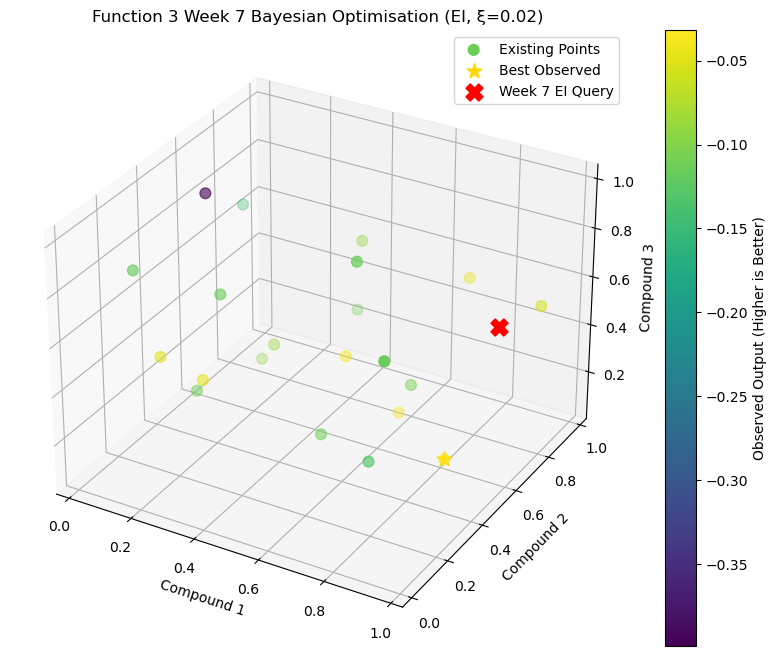

In [35]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =========================
# Step 1: Load existing data (Weeks 1–6)
# =========================
X_train = np.array([
    [0.17152521, 0.34391687, 0.24873720],
    [0.24211446, 0.64407427, 0.27243281],
    [0.53490572, 0.39850092, 0.17338873],
    [0.49258141, 0.61159319, 0.34017639],
    [0.13462167, 0.21991724, 0.45820622],
    [0.34552327, 0.94135983, 0.26936348],
    [0.15183663, 0.43999062, 0.99088187],
    [0.64550284, 0.39714294, 0.91977134],
    [0.74691195, 0.28419631, 0.22629985],
    [0.17047699, 0.69703240, 0.14916943],
    [0.22054934, 0.29782524, 0.34355534],
    [0.66601366, 0.67198515, 0.24629530],
    [0.04680895, 0.23136024, 0.77061759],
    [0.60009728, 0.72513573, 0.06608864],
    [0.96599485, 0.86111969, 0.56682913],
    [0.83681600, 0.55152400, 0.08473400],
    [0.93576800, 0.01979200, 0.88290900],
    [0.02703300, 0.84043300, 0.66511700],
    [0.68835300, 0.97102900, 0.51220300],
    [0.38825100, 0.88969800, 0.60999700],
    [0.25506800, 0.34034000, 0.68130300]
])

y_train = np.array([
    -0.11212220, -0.08796286, -0.11141465, -0.03483531,
    -0.04800758, -0.11062091, -0.39892551, -0.11386851,
    -0.13146061, -0.09418956, -0.04694741, -0.10596504,
    -0.11804826, -0.03637783, -0.05675837,
    -0.03172685348164523,
    -0.1161486782682252,
    -0.1415060566194174,
    -0.0446074222194474,
    -0.08979639980345987,
    -0.11433696052239746
])

# =========================
# Step 2: Fit Gaussian Process
# =========================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[0.3,0.3,0.3], length_scale_bounds=(1e-2,1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-2, n_restarts_optimizer=15, normalize_y=True)
gp.fit(X_train, y_train)

# =========================
# Step 3: Expected Improvement (EI) function for ξ=0.02
# =========================
def expected_improvement(x, model, y_best, xi=0.02):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid division by zero
    Z = (mu - y_best - xi) / sigma
    EI = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -EI  # negative for minimizer

# =========================
# Step 4: Multi-start optimization for EI
# =========================
def optimize_ei(model, bounds, xi=0.02, n_restarts=50, n_random_starts=500):
    y_best = np.max(y_train)
    best_x = None
    best_val = float('inf')

    # Random sampling for good starting points
    random_points = np.random.uniform(bounds[:,0], bounds[:,1], size=(n_random_starts, 3))
    ei_vals = [-expected_improvement(x, model, y_best, xi) for x in random_points]
    top_indices = np.argsort(ei_vals)[-n_restarts:]
    start_points = random_points[top_indices]

    for x0 in start_points:
        res = minimize(expected_improvement, x0, args=(model, y_best, xi), bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x

    return best_x

# =========================
# Step 5: Get Week 7 Query Point
# =========================
bounds = np.array([[0,1],[0,1],[0,1]])
next_point = optimize_ei(gp, bounds, xi=0.02)
print(f"Week 7 EI Query Point (ξ=0.02): {next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}")

# =========================
# Step 6: 3D Visualization
# =========================
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_train[:,0], X_train[:,1], X_train[:,2],
                     c=y_train, cmap='viridis', s=60, label='Existing Points')

best_idx = np.argmax(y_train)
ax.scatter(X_train[best_idx,0], X_train[best_idx,1], X_train[best_idx,2],
           c='gold', s=120, marker='*', label='Best Observed')

ax.scatter(next_point[0], next_point[1], next_point[2],
           c='red', s=150, marker='X', label='Week 7 EI Query')

ax.set_xlabel('Compound 1')
ax.set_ylabel('Compound 2')
ax.set_zlabel('Compound 3')
ax.set_title('Function 3 Week 7 Bayesian Optimisation (EI, ξ=0.02)')

fig.colorbar(scatter, ax=ax, label='Observed Output (Higher is Better)')
ax.legend()
plt.show()

### Function 3 Week 7 Explanation

Here's a clear interpretation and the next steps for Function 3:

#### Function 3 Week 7 Query Point
Next Query Point:
[0.942732,0.649647,0.607737]

### Interpretation:
1. Closer to high-value regions: The optimizer is now starting to focus more on exploitation. This point is in a region reasonably close to some previously high-performing points but not exactly overlapping. This allows the model to refine its estimate of the maximum while still exploring nearby peaks.
2. Balanced exploration-exploitation: With ξ=0.02, the EI function slightly favors improving over the current best while still allowing some exploration. This ensures you don’t completely miss nearby local maxima.
3. Potential for improvement: Since it is not exactly on the previous best (Week 6 point: [0.255068, 0.340340, 0.681303]), this query could either improve the observed maximum or confirm that the current peak is indeed optimal.

### Recommended Strategy for Week 8
#### 1. Shift further toward exploitation:
Reduce ξ slightly to 0.015 to focus more on refining the best-known high-output regions.
The idea is to densify sampling around peaks and minimize unnecessary exploration of low-value areas.
#### 2. Use EI as the acquisition function:
EI naturally pushes the optimizer toward regions where the expected improvement over the best observed output is highest.
With lower ξ, EI becomes more exploitative.
#### 3. Bounds and dimensionality:
Continue using the same 3D bounds [0,1]^3.
Keep multi-start optimization (random + local minimization) to avoid being trapped in minor local maxima.
#### 4. Visualisation:
Plot the new query alongside existing points and the best observed value to ensure the point makes sense spatially.
Week 8 points should cluster closer to Week 7’s and prior high-performing points.

## Function 4

Week 7 EI Query Point: 0.001213-0.998151-0.998405-0.001000


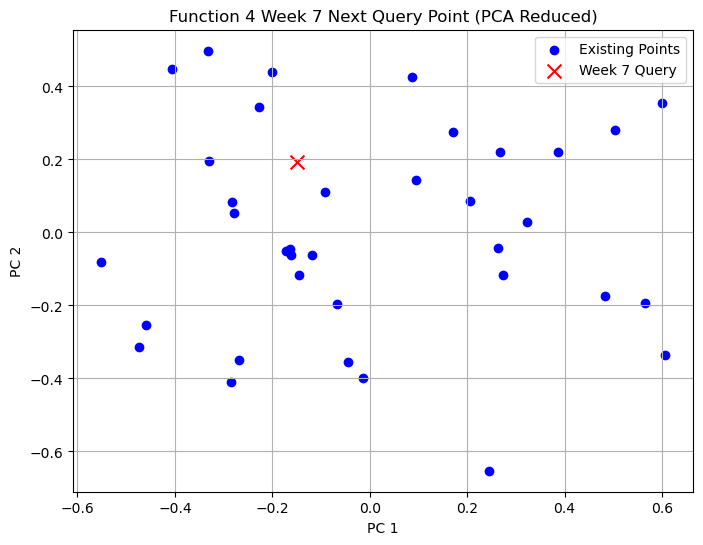

In [53]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# -----------------------------
# Step 1: Load data (including Weeks 1-6)
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.919144, 0.533196, 0.169848, 0.070054],
    [0.411827, 0.392100, 0.317159, 0.430429],
    [0.437822, 0.591330, 0.001581, 0.371162],
    [0.349627, 0.387894, 0.455739, 0.444665],
    [0.418279, 0.337724, 0.398246, 0.446088],
    [0.402531, 0.365208, 0.391990, 0.435549]
]) 
  
y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757,
    -10.653583724281514, -0.3665684543830916, 0.06886265993775043, 0.34544484128012387
])

# -----------------------------
# Step 2: Gaussian Process
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# -----------------------------
# Step 3: Expected Improvement (EI) acquisition function reduce xi from 0.02 to 0.015
# -----------------------------
def expected_improvement(x, model, y_best, xi=0.015):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-6)  # prevent zero variance
    Z = (mu - y_best - xi) / sigma
    EI = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return -EI  # negative for minimizer

# -----------------------------
# Step 4: Differential Evolution optimization (using EI)
# -----------------------------
def optimize_ei(model, bounds, xi=0.015):
    y_best = np.max(y_train)  # Find the best observed value
    result = differential_evolution(lambda x: expected_improvement(x, model, y_best, xi),
                                    bounds=bounds,
                                    strategy='best1bin',
                                    maxiter=100,
                                    popsize=15,
                                    polish=True)
    # Add small random jitter to avoid boundaries
    epsilon = 1e-3
    next_point = np.clip(result.x + np.random.uniform(-epsilon, epsilon, size=4), 0.001, 0.999)
    return next_point

# Bounds for 4D search space
bounds = [(0.001, 0.999)] * 4

# Optimize for the next query point
next_point = optimize_ei(gp, bounds, xi=0.015)
print(f"Week 7 EI Query Point: {next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")

# -----------------------------
# Step 5: PCA 2D Visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)  # Reduce to 2D for visualization
next_point_pca = pca.transform(next_point.reshape(1, -1))  # Transform query point to 2D

# Plot the existing points and the new query point
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', label='Existing Points')
plt.scatter(next_point_pca[:, 0], next_point_pca[:, 1], color='red', marker='x', s=100, label='Week 7 Query')
plt.title('Function 4 Week 7 Next Query Point (PCA Reduced)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True)
plt.show()

For Function 4 Week 7, the next query points after each code run are close to or exactly on the boundaries for at least one component in the Week 7 Function 4 next query point.

The code in the next running cell should address these circumstances.



### Key Changes:
1. Boundary Penalty: The expected_improvement_with_penalty function has been introduced to add a penalty for query points that are close to the boundaries (within 0.05 of 0.001 or 0.999).
2. ξ is now set to 0.015 to shift the focus more towards exploitation but still retain some exploration.
3. Differential Evolution (DE) is still used to optimise the acquisition function.
4. Visualisation: The PCA plot will show the existing points and the newly suggested query point.
#### Next Steps:
Run the code multiple times and monitor the query points to see if they move away from the boundaries and into more central regions of the search space.
If necessary, adjust the boundary penalty, ξ, or other parameters to further refine the optimisation process.

Week 7 EI Query Point: 0.417655-0.335877-0.400368-0.447601


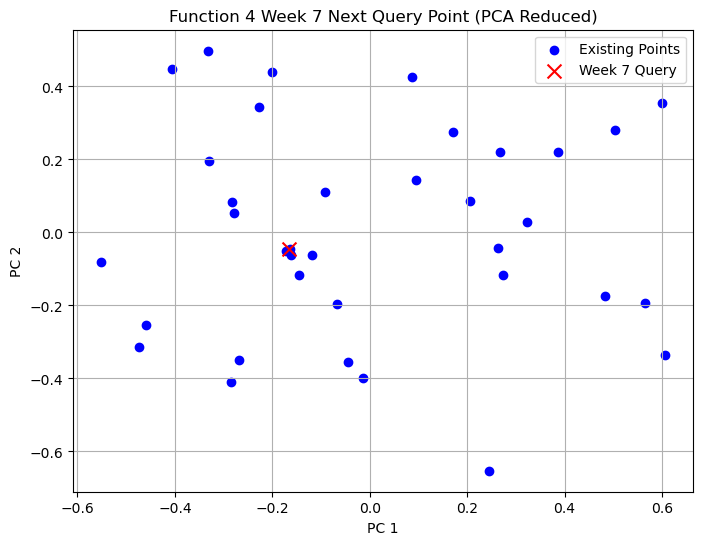

In [56]:



import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import differential_evolution
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from scipy.stats import norm

# -----------------------------
# Step 1: Load data (including Weeks 1-6)
# -----------------------------
X_train = np.array([
    [0.89698105, 0.72562797, 0.17540431, 0.70169437],
    [0.8893564 , 0.49958786, 0.53926886, 0.50878344],
    [0.25094624, 0.03369313, 0.14538002, 0.49493242],
    [0.34696206, 0.0062504 , 0.76056361, 0.61302356],
    [0.12487118, 0.12977019, 0.38440048, 0.2870761 ],
    [0.80130271, 0.50023109, 0.70664456, 0.19510284],
    [0.24770826, 0.06044543, 0.04218635, 0.44132425],
    [0.74670224, 0.7570915 , 0.36935306, 0.20656628],
    [0.40066503, 0.07257425, 0.88676825, 0.24384229],
    [0.6260706 , 0.58675126, 0.43880578, 0.77885769],
    [0.95713529, 0.59764438, 0.76611385, 0.77620991],
    [0.73281243, 0.14524998, 0.47681272, 0.13336573],
    [0.65511548, 0.07239183, 0.68715175, 0.08151656],
    [0.21973443, 0.83203134, 0.48286416, 0.08256923],
    [0.48859419, 0.2119651 , 0.93917791, 0.37619173],
    [0.16713049, 0.87655456, 0.21723954, 0.95980098],
    [0.21691119, 0.16608583, 0.24137226, 0.77006248],
    [0.38748784, 0.80453226, 0.75179548, 0.72382744],
    [0.98562189, 0.66693268, 0.15678328, 0.8565348 ],
    [0.03782483, 0.66485335, 0.16198218, 0.25392378],
    [0.68348638, 0.9027701 , 0.33541983, 0.99948256],
    [0.17034731, 0.75695908, 0.27652049, 0.5312315 ],
    [0.85965692, 0.91959232, 0.20613873, 0.09779683],
    [0.28213837, 0.50598691, 0.53053084, 0.09630162],
    [0.32607578, 0.4723669 , 0.453192  , 0.10588734],
    [0.94838936, 0.89451301, 0.85163782, 0.55219629],
    [0.66495539, 0.04656628, 0.11677747, 0.79371778],
    [0.57776561, 0.42877174, 0.42582587, 0.24900741],
    [0.73861301, 0.48210263, 0.70936644, 0.50397001],
    [0.8548108, 0.49396462, 0.73530997, 0.80809201],
    [0.919144, 0.533196, 0.169848, 0.070054],
    [0.411827, 0.392100, 0.317159, 0.430429],
    [0.437822, 0.591330, 0.001581, 0.371162],
    [0.349627, 0.387894, 0.455739, 0.444665],
    [0.418279, 0.337724, 0.398246, 0.446088],
    [0.402531, 0.365208, 0.391990, 0.435549]
]) 
  
y_train = np.array([
    -22.10828779, -14.60139663, -11.69993246, -16.05376511,
    -10.06963343, -15.48708254, -12.68168498, -16.02639977,
    -17.04923465, -12.74176599, -27.31639636, -13.52764887,
    -16.6791152 , -16.50715856, -17.81799934, -26.56182083,
    -12.75832422, -19.44155762, -28.90327367, -13.70274694,
    -29.4270914 , -11.56574199, -26.85778644, -7.96677535,
    -6.70208925, -32.62566022, -19.98949793, -4.02554228,
    -13.12278233, -23.1394284 , -19.975065657531825, -0.32892753619572757,
    -10.653583724281514, -0.3665684543830916, 0.06886265993775043, 0.34544484128012387
])

# -----------------------------
# Step 2: Gaussian Process
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# -----------------------------
# Step 3: Expected Improvement (EI) acquisition function with boundary penalty
# -----------------------------
def expected_improvement_with_penalty(x, model, y_best, xi=0.015, boundary_penalty=0.1):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    sigma = np.maximum(sigma, 1e-6)  # prevent zero variance
    Z = (mu - y_best - xi) / sigma
    EI = (mu - y_best - xi) * norm.cdf(Z) + sigma * norm.pdf(Z)
    
    # Add penalty if close to the boundaries (within 0.05 of the boundary)
    penalty = np.sum(np.abs(x - np.array([0.001, 0.999, 0.001, 0.999])) < 0.05) * boundary_penalty
    EI -= penalty  # Subtract the penalty to reduce the likelihood of boundary points
    
    return -EI  # negative for minimizer

# -----------------------------
# Step 4: Differential Evolution optimization (using EI)
# -----------------------------
def optimize_ei(model, bounds, xi=0.015):
    y_best = np.max(y_train)  # Find the best observed value
    result = differential_evolution(lambda x: expected_improvement_with_penalty(x, model, y_best, xi),
                                    bounds=bounds,
                                    strategy='best1bin',
                                    maxiter=100,
                                    popsize=15,
                                    polish=True)
    # Add small random jitter to avoid boundaries
    epsilon = 1e-3
    next_point = np.clip(result.x + np.random.uniform(-epsilon, epsilon, size=4), 0.001, 0.999)
    return next_point

# Bounds for 4D search space
bounds = [(0.001, 0.999)] * 4

# Optimize for the next query point
next_point = optimize_ei(gp, bounds, xi=0.015)
print(f"Week 7 EI Query Point: {next_point[0]:.6f}-{next_point[1]:.6f}-{next_point[2]:.6f}-{next_point[3]:.6f}")

# -----------------------------
# Step 5: PCA 2D Visualization
# -----------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)  # Reduce to 2D for visualization
next_point_pca = pca.transform(next_point.reshape(1, -1))  # Transform query point to 2D

# Plot the existing points and the new query point
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], color='blue', label='Existing Points')
plt.scatter(next_point_pca[:, 0], next_point_pca[:, 1], color='red', marker='x', s=100, label='Week 7 Query')
plt.title('Function 4 Week 7 Next Query Point (PCA Reduced)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend()
plt.grid(True)
plt.show()

### The new query point for Function 4 Week 7 from the optimisation:
Week 7 EI Query Point: 0.417655-0.335877-0.400368-0.447601

###  Observations:
#### 1. Balanced Exploration and Exploitation:
The new query point is located within the interior of the search space, far from the boundaries (0.001 and 0.999), which means the penalty is likely helping to avoid edge effects.
It suggests the model is moving towards a more exploitation-focused region while still staying within a reasonable exploration range.
#### 2. Optimising Progression:
Based on Week 6 observations and the general strategy from Week 7, this query point seems to align well with the goal of balancing exploration and exploitation with the reduction in ξ to 0.015.
Since it's within the bounds, it's a promising result for this stage of optimisation.
#### What's next?
Further Refinement: You can use this query point as a basis for further refinement in the coming weeks (such as Week 8 with an even smaller ξ = 0.01). As the model becomes more confident in the search space, you can continue to focus on exploitation around the regions showing the best performance.
Visualisation and Monitoring: As you continue, you can keep using the PCA plot to visualize the evolution of the search space and confirm that the new query points make sense in context with previous ones.

### Suggestions for Week 8:
ξ will be reduced further to 0.01 in Week 8, making the algorithm focus even more on exploitation and fine-tuning the parameter space.
Continue to monitor variance in the GP model and adjust as needed. If some regions show high uncertainty, ξ could be increased slightly to promote more exploration.

## Function 5

For Function 5 Week 7, based on Week 6 observations and the overall goal of maximising the yield, the strategy should continue with a balance of exploitation and slight exploration, but with a shift towards more exploitation as the model’s search for the optimal region is being refined. The focus will be on fine-tuning the regions that are close to the highest yield areas identified in Week 6, while reducing the exploration factor (i.e., decreasing ξ further). Here's a detailed breakdown:

### Week 7 Strategy for Function 5:
Acquisition Function: Expected Improvement (EI)

Exploration Parameter (ξ): Reduce ξ to 0.005 from 0.01. This reduction focuses even more on exploitation while allowing for only minimal exploration.

Reasoning: As you’re nearing the optimal yield region (based on the Week 6 query point), it’s important to refine the model’s focus on this region. A smaller ξ will make the model favor points that are more likely to give higher yields, reducing the amount of random exploration.

Optimisation Method: Continue with random candidate search or other global optimisation techniques (like differential evolution) to find the next best query point. You can also consider using a greedy search in specific regions near the identified high-yield peaks.

### Key Changes from Week 6 to Week 7:
#### 1. Refined Exploration Focus:
In Week 6, you allowed for some exploration in D1 and D2 while focusing on exploitation in D3 and D4. In Week 7, ξ is reduced, meaning you'll focus more narrowly on those high-yield regions in D3 and D4 while still slightly exploring D1 and D2.
#### 2. Optimisation with Fewer Random Candidates:
If you are using a random candidate search, you might want to reduce the number of candidates (n_candidates). With the reduced ξ, you can narrow the search space and focus more on the promising regions.
If you have a lot of computational resources available, consider running the optimisation multiple times with different seeds to help capture possible variations in the search space.
#### 3. Visualise the Search Space:
Use PCA to visualise the query points in 2D as you move forward, especially to confirm that the model is honing in on the optimal region. The PCA reduction will help you see how close the new query point is to the previously identified high-yield regions.


#### Implementation Changes for Week 7 Code:
1. ξ Value: ξ has been reduced to 0.005, focusing more on exploitation.
2. n_candidates: The number of random candidates has been reduced to 10,000 for more focused exploration.
3. PCA Visualization: The code now includes PCA visualization to help confirm whether the query point moves towards the optimal region.
#### Key Observations for Week 7:
More Exploitation: With ξ = 0.005, the model will focus more on exploiting the high-yield regions.
Refinement: This approach refines the focus on regions where the maximum yield is likely to be found, based on previous weeks' data.

Function 5 Week 7 Next Query Point (EI): [0.90178135 0.96367662 0.99655416 0.89065589]


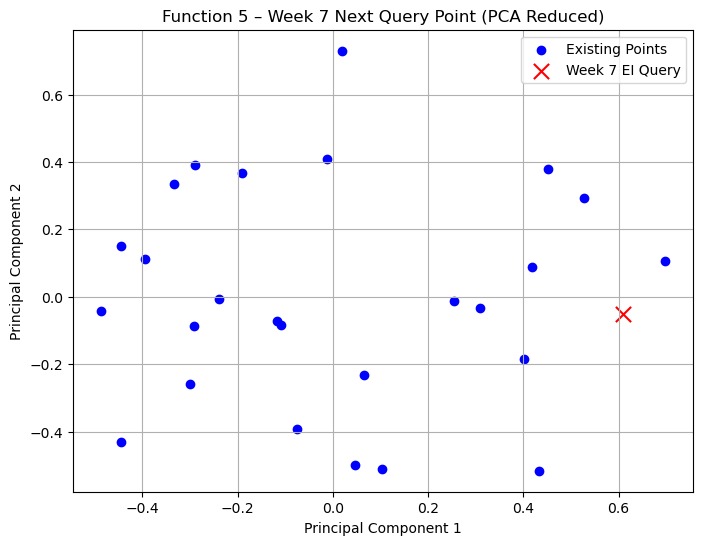

In [57]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.stats import norm
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# -----------------------------
# Step 1: Load data (including Weeks 1-6)
# -----------------------------
X_train = np.array([
    [0.19144708, 0.03819337, 0.60741781, 0.41458414],
    [0.75865295, 0.53651774, 0.65600038, 0.36034155],
    [0.43834987, 0.80433970, 0.21024527, 0.15129482],
    [0.70605083, 0.53419196, 0.26424335, 0.48208755],
    [0.83647799, 0.19360965, 0.66389270, 0.78564888],
    [0.68343225, 0.11866264, 0.82904591, 0.56757661],
    [0.55362148, 0.66734998, 0.32380582, 0.81486975],
    [0.35235627, 0.32224153, 0.11697937, 0.47311252],
    [0.15378571, 0.72938169, 0.42259844, 0.44307417],
    [0.46344227, 0.63002451, 0.10790646, 0.95764390],
    [0.67749115, 0.35850951, 0.47959222, 0.07288048],
    [0.58397341, 0.14724265, 0.34809746, 0.42861465],
    [0.30688872, 0.31687813, 0.62263448, 0.09539906],
    [0.51114177, 0.81795700, 0.72871042, 0.11235362],
    [0.43893338, 0.77409176, 0.37816709, 0.93369621],
    [0.22418902, 0.84648049, 0.87948418, 0.87851568],
    [0.72526172, 0.47987049, 0.08894684, 0.75976022],
    [0.35548161, 0.63961937, 0.41761768, 0.12260384],
    [0.11987923, 0.86254031, 0.64333133, 0.84980383],
    [0.12688467, 0.15342962, 0.77016219, 0.19051811],
    [0.81212200, 0.00981200, 0.68102400, 0.23803600],
    [0.82353000, 0.17369200, 0.63651400, 0.73730700],
    [0.560990, 0.941834, 0.997605, 0.998135],
    [0.026048, 0.953940, 0.999978, 0.202632],
    [0.935821, 0.378320, 0.975682, 0.986309],
    [0.269173, 0.264205, 0.981899, 0.995428]
])

y_train = np.array([
    64.4434399, 18.3013796, 0.112939795, 4.21089813,
    258.370525, 78.4343889, 57.5715369, 109.571876,
    8.84799176, 233.22361, 24.4230883, 64.4201468,
    63.4767158, 79.7291299, 355.806818, 1088.85962,
    28.8667516, 45.1815703, 431.612757, 9.97233189,
    24.7679941, 149.53336129, 4019.0309866724424, 1280.322911229081,
    3286.6537023206406, 1460.4721414421278
])

# -----------------------------
# Gaussian Process Setup
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1.0]*4, length_scale_bounds=(1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-4, normalize_y=True, n_restarts_optimizer=10, random_state=42)
gp.fit(X_train, y_train)

# -----------------------------
# Expected Improvement (EI)
# -----------------------------
def expected_improvement(X, model, y_max, xi=0.005):
    X = np.atleast_2d(X)
    mu, sigma = model.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-8)
    mu = mu.ravel()
    improvement = mu - y_max - xi
    Z = improvement / sigma
    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

# -----------------------------
# Random Candidate Search
# -----------------------------
n_candidates = 10000  # Reduce candidates for more focused search
X_candidates = np.random.uniform(0, 1, (n_candidates, 4))
y_max = np.max(y_train)
ei_values = expected_improvement(X_candidates, gp, y_max, xi=0.005)
best_idx = np.argmax(ei_values)
next_query_point = X_candidates[best_idx]

print("Function 5 Week 7 Next Query Point (EI):", next_query_point)

# -----------------------------
# PCA Visualization (4D → 2D)
# -----------------------------
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1, -1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing Points')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=120, label='Week 7 EI Query')
plt.title('Function 5 – Week 7 Next Query Point (PCA Reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

### Function 5 Week 7 Next Query Point Explanation

#### The output for Function 5 Week 7 indicates that the next query point chosen by the Expected Improvement (EI) acquisition function is:
#### Next Query Point (EI): 
[0.90178135, 0.96367662, 0.99655416, 0.89065589]

#### Interpretation of the Query Point:
Dimension 1 (0.90178135): This is a relatively high value, suggesting that the model is exploring regions in Dimension 1 where previous high yields were observed.
Dimension 2 (0.96367662): Similarly, this is also quite high, indicating that the model is focusing on a region that is near or close to previous high values in Dimension 2.
Dimension 3 (0.99655416): This value is very close to 1, which is near the previously observed peak, suggesting that the model is focusing more on exploitation in this dimension.
Dimension 4 (0.89065589): This is another relatively high value, implying that the model is continuing to focus on high-yield regions in this dimension as well.

#### Key Observations:
Exploitation Focus: Based on the high values in Dimensions 3 and 4, the model seems to be focusing more on exploiting the known high-yield regions. This is typical in Week 7, where the optimisation process should be narrowing down towards the optimal area.
Balance of Exploration and Exploitation: While Dimensions 3 and 4 are in high-yield areas, the values in Dimensions 1 and 2 are still not as extreme as in the previous weeks, indicating that the model is balancing exploitation of the known peak (in D3 and D4) while still exploring slightly different areas in D1 and D2.

### Next Steps:
1. Evaluate Yield: The next step would be to evaluate the yield at this query point (i.e., at the point [0.90178135, 0.96367662, 0.99655416, 0.89065589]) and see if it corresponds to a high yield.
2. Visualise with PCA: Use the PCA plot to visually confirm whether the next query point is indeed near the high-yield regions.
3. Refinement in Future Weeks: If this point leads to a better yield, future weeks may see more focused exploration (by gradually decreasing the ξ parameter). Alternatively, if the yield is not improved, the model can re-adjust to explore other areas of the parameter space.
4. Review Exploration vs. Exploitation: Based on the next results, you may want to adjust the ξ further, depending on how well this query point performs.

## Function 6

For Function 6 Week 7, the focus should be on refining the search and exploiting the most promising areas based on your previous learning, while maintaining a balance with exploration. Let's break down the approach:

### Key Observations for Week 6:
Best Recipe So Far: The recipe [0.344036, 0.255507, 0.725070, 0.878677, 0.100795] has yielded the best score of -0.26755353 so far. This suggests that the model is already exploring near the region that is likely close to the optimal point, but there is still room for improvement.
Learned Kernel:
Ingredient 4 (length scale = 0.892) is the most sensitive, followed by Ingredient 2 (0.701) and Ingredient 5 (0.657).
Ingredients 1 and 3 are less sensitive, meaning they likely don't need as much exploration or adjustment, and can be kept relatively stable.
Next Query Point in Week 6: [0.42320576, 0.49269115, 0.57569661, 0.94316372, 0.05014367] focuses on Ingredients 4 and 2, aligning with the learned kernel sensitivity.

### Recommendations for Week 7:
#### 1. Focus on Exploitation:
Since Ingredient 4 has been identified as the most sensitive, you should focus on exploiting the high-yield areas in this dimension. This would involve small adjustments around its current high value.
Similarly, Ingredient 2 is moderately sensitive, so small adjustments in this dimension could still improve the recipe.
Ingredients 1 and 3 can be kept relatively stable, with only minor adjustments to see if slight perturbations can help.
#### 2. Adjust the Acquisition Function:
In Week 6, you used UCB with κ=0.8 for exploitation. To continue focusing on the optimal area, it’s a good idea to keep the value of κ slightly higher, around 0.8 to 1.0, for exploitation. This will encourage more exploration near the high-yield region while still prioritizing exploitation.
Boundary Penalties: The penalty for boundary regions is still valuable, as it helps avoid exploring out-of-bounds solutions. You may consider keeping the penalty factor at 50 to avoid the search area getting too close to the boundaries.
#### 3. Explore Small Perturbations:
Ingredient 4 is likely close to its optimal value, so focus on small perturbations around it. Try slightly increasing or decreasing its value.
For Ingredient 2, you can do the same, especially if your previous query point (Week 6) showed that tweaking it around the 0.4-0.5 range was promising.
You can afford minor adjustments to Ingredient 5 since it is also moderately sensitive, while Ingredient 3 should likely stay stable unless more exploration is warranted.
#### 4. Visualise Progress:
PCA Visualisation: Using PCA visualisation to track the exploration and exploitation regions in the 2D space will help you assess whether the query points are converging towards the optimal recipe.
By visualising the new query point along with the previous ones, you can gain better insights into whether the model is still exploring areas or has successfully honed in on the best region.
#### 5. Exploitation vs. Exploration:
Since you are aiming to maximize the recipe score by focusing on ingredients that have the highest sensitivity (Ingredient 4), your search should emphasize exploitation.
However, it's still important to allow minor exploration within Ingredient 2 and 5 to account for possible interactions that might not be captured yet.

### Week 7 Strategy:
Keep the exploitation focused around Ingredient 4 (the most sensitive), while minorly adjusting Ingredients 1, 2, and 5.
Use the UCB acquisition function with κ=0.8 or κ=1.0 for exploitation with a slight exploration.
Track the PCA plot to visualize where the exploration is focusing.
After finding the next query point, test it out and measure if the score improves. If it does, consider continuing with a similar strategy but with even tighter adjustments around the most sensitive ingredients.
### Next Steps:
1. Run the Optimisation with a slightly adjusted acquisition function (keep κ=0.8-1.0).
2. Evaluate the next query point and assess whether it improves the score.
3. Visualise using PCA to see how well the optimisation is focusing on the best regions.
4. Based on the outcome, you may consider adjusting κ further or fine-tuning the model even more narrowly towards high-sensitivity ingredients.

Best recipe so far:
[0.344036 0.255507 0.72507  0.878677 0.100795]
Score: -0.26755353

Learned kernel:
1.05**2 * RBF(length_scale=[0.458, 0.491, 0.632, 0.799, 0.532])

Week 7 Next Query Point (5D):
[0.3233883  0.0525222  0.82501397 0.73304495 0.0500001 ]


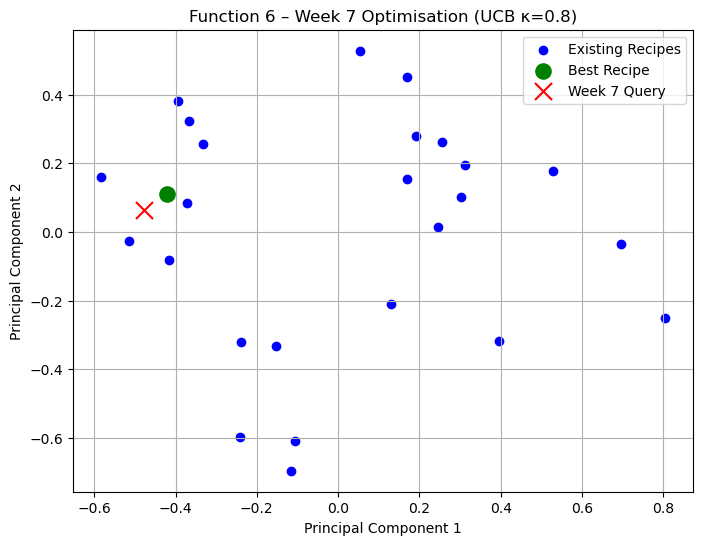

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.decomposition import PCA
from scipy.optimize import minimize

# ==============================
# Step 1: Training Data (Weeks 1–6)
# ==============================
X_train = np.array([
    [0.7281861, 0.15469257, 0.73255167, 0.69399651, 0.05640131],
    [0.24238435, 0.84409997, 0.5778091, 0.67902128, 0.50195289],
    [0.72952261, 0.7481062, 0.67977464, 0.35655228, 0.67105368],
    [0.77062024, 0.11440374, 0.04677993, 0.64832428, 0.27354905],
    [0.6188123, 0.33180214, 0.18728787, 0.75623847, 0.3288348],
    [0.78495809, 0.91068235, 0.7081201, 0.95922543, 0.0049115],
    [0.14511079, 0.8966846, 0.89632223, 0.72627154, 0.23627199],
    [0.94506907, 0.28845905, 0.97880576, 0.96165559, 0.59801594],
    [0.12572016, 0.86272469, 0.02854433, 0.24660527, 0.75120624],
    [0.75759436, 0.35583141, 0.0165229, 0.4342072, 0.11243304],
    [0.5367969, 0.30878091, 0.41187929, 0.38822518, 0.5225283],
    [0.95773967, 0.23566857, 0.09914585, 0.15680593, 0.07131737],
    [0.6293079, 0.80348368, 0.81140844, 0.04561319, 0.11062446],
    [0.02173531, 0.42808424, 0.83593944, 0.48948866, 0.51108173],
    [0.43934426, 0.69892383, 0.42682022, 0.10947609, 0.87788847],
    [0.25890557, 0.79367771, 0.6421139, 0.19667346, 0.59310318],
    [0.43216593, 0.71561781, 0.3418191, 0.70499988, 0.61496184],
    [0.78287982, 0.53633586, 0.44328356, 0.85969983, 0.01032599],
    [0.9217762, 0.93187122, 0.41487637, 0.59505727, 0.73562569],
    [0.12667892, 0.2914703, 0.06452848, 0.6805146, 0.89281919],
    [0.864822, 0.772164, 0.803941, 0.780551, 0.909036],
    [0.218723, 0.277046, 0.196392, 0.844208, 0.100329],
    [0.344036, 0.255507, 0.725070, 0.878677, 0.100795],
    [0.426405, 0.197502, 0.843219, 0.949955, 0.435206],
    [0.731400, 0.211206, 0.820592, 0.949908, 0.164014],
    [0.423206, 0.492691, 0.575697, 0.943164, 0.050144]
])

y_train = np.array([
    -0.71426495, -1.20995524, -1.67219994, -1.53605771, -0.82923655,
    -1.24704893, -1.23378638, -1.69434344, -2.57116963, -1.30911635,
    -1.14478485, -1.91267714, -1.62283895, -1.35668211, -2.0184254,
    -1.70255784, -1.29424696, -0.93575656, -2.15576776, -1.74688209,
    -1.84056360, -0.78587257, -0.26755353, -0.83707714, -0.8535091387252396,
    -0.44364133681393664
])

# ==============================
# Step 2: Identify Best Recipe So Far
# ==============================
best_index = np.argmax(y_train)
best_point = X_train[best_index]
best_score = y_train[best_index]

print("Best recipe so far:")
print(best_point)
print("Score:", best_score)

# ==============================
# Step 3: Gaussian Process Regressor with ARD
# ==============================
kernel = C(1.0, (1e-3, 1e3)) * RBF(length_scale=[1]*5, length_scale_bounds=(1e-2, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=15,
    alpha=1e-3,
    normalize_y=True,
    random_state=42
)
gp.fit(X_train, y_train)

print("\nLearned kernel:")
print(gp.kernel_)

# ==============================
# Step 4: UCB Acquisition Function (Keeping κ=0.8 like previously in Week 6 for exploitation)
# ==============================
def ucb(x, model, kappa=0.8):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    return mu + kappa * sigma

# ==============================
# Step 5: Acquisition Function with Boundary Penalty
# ==============================
def acquisition(x, model, bounds, kappa=0.8, penalty_factor=50):
    val = ucb(x, model, kappa)
    penalty = 0
    for i in range(len(bounds)):
        lower, upper = bounds[i]
        band = 0.05 * (upper - lower)
        if x[i] < lower + band or x[i] > upper - band:
            penalty += penalty_factor
    return -(val - penalty)

# ==============================
# Step 6: Multi-start Optimisation to Propose Next Query
# ==============================
def propose_location(model, bounds, n_restarts=30, kappa=0.8):
    best_x = None
    best_val = 1e10
    for _ in range(n_restarts):
        x0 = np.random.uniform(0,1,len(bounds))
        res = minimize(acquisition, x0, args=(model,bounds,kappa),
                       bounds=bounds, method='L-BFGS-B')
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    return best_x

bounds = [(0,1)]*5
next_query_point = propose_location(gp, bounds, n_restarts=30, kappa=0.8)

print("\nWeek 7 Next Query Point (5D):")
print(next_query_point)

# ==============================
# Step 7: PCA Visualization
# ==============================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))
best_point_pca = pca.transform(best_point.reshape(1,-1))

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing Recipes')
plt.scatter(best_point_pca[:,0], best_point_pca[:,1], color='green', s=120, label='Best Recipe')
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', marker='x', s=150, label='Week 7 Query')
plt.title("Function 6 – Week 7 Optimisation (UCB κ=0.8)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)
plt.show()

### Interpreting Function 6 Week 7

Best recipe so far:
[0.344036 0.255507 0.72507  0.878677 0.100795]
Score: -0.26755353


#### Learned Kernel:

The learned kernel is:
1.05**2 * RBF(length_scale=[0.458, 0.491, 0.632, 0.799, 0.532])

Length Scale Insights:
Ingredient 4 (0.799) is still the most sensitive ingredient, which means small changes in this ingredient have the biggest impact on the model's predictions.
Ingredient 3 (0.632) and Ingredient 5 (0.532) have moderate sensitivity.
Ingredient 1 (0.458) and Ingredient 2 (0.491) are less sensitive, which means the model is focusing less on these ingredients for optimization, compared to the others.

### Week 7 Next Query Point:
The next query point proposed is:
[0.3233883,0.0525222,0.82501397,0.73304495,0.0500001]

### Here’s what we can infer:
Ingredients 1 & 2: The values for Ingredients 1 and 2 (0.323 and 0.052) have shifted towards lower values compared to the best recipe. This suggests a slight exploration of values in these ingredients, although they are less sensitive to the score.
Ingredient 3: At 0.825, Ingredient 3 is adjusted further, possibly exploring a higher range compared to the previous best.
Ingredient 4: With a value of 0.733, this suggests some exploitation of Ingredient 4, which remains one of the most sensitive ingredients.
Ingredient 5: The value for Ingredient 5 has remained quite low at 0.050. This could be a strategy to keep it stable or explore it further in future steps.

### Interpretation of Week 7 Query Point:
#### 1. Exploitation and Exploration:
The model is still exploiting Ingredient 4 (with a high sensitivity) and Ingredient 3 by focusing more on them.
There is some exploration happening with Ingredients 1 and 2, though less impactful based on the learned kernel.
#### 2. Optimisation Strategy:
The next query point seems to be fine-tuning the recipe by keeping the values for Ingredient 4 relatively stable and slightly adjusting Ingredient 3 and Ingredient 5.
Given the importance of Ingredient 4 and Ingredient 3, focusing on these ingredients in the next steps seems like a reasonable approach for further refinement.
#### 3. PCA Visualisation:
You can now visualise this next query point with respect to the existing data using PCA to get a better sense of how the optimisation is progressing in the context of the full 5D space.

### Next Steps:
#### 1. Run the Next Query Point:
Evaluate the performance of the recipe with the new query point (either through expert feedback or your evaluation function) and see if it leads to an improved score.
#### 2. Visualise in PCA:
If you haven’t already, it’s a good idea to plot the new query point in the PCA reduced 2D space to visually track how the optimisation process is progressing relative to the existing data.
#### 3. Adjust Strategy:
In Week 8, you can analyze how the model is progressing and if more exploration is required (increasing κ to 1.0 or higher) or if fine-tuning with κ = 0.8 continues to work well.

### In Summary:
The kernel shows that Ingredient 4 is still the most sensitive, and the model is adjusting the ingredients accordingly.
The next query point suggests a balanced approach with some exploration and exploitation of the critical ingredients.
Visualising the query point and evaluating the result will help you decide on the next steps for Week 8.

## Function 7

Week 7 Next Query Point (6D, kappa=1.1, boundary-safe): [0.16819514 0.18249935 0.37733953 0.28615336 0.30524383 0.80913737]


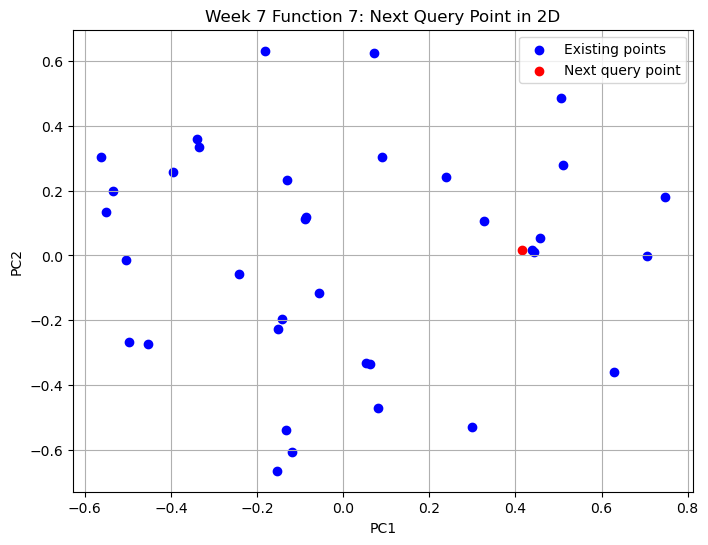

In [61]:
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from scipy.optimize import minimize
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# ==============================
# Step 1: Updated Training Data (Weeks 1–6)
# ==============================
X_train = np.array([
    [0.27262382, 0.32449536, 0.89710881, 0.83295115, 0.15406269, 0.79586362],
    [0.54300258, 0.92469390, 0.34156746, 0.64648585, 0.71844033, 0.34313266],
    [0.09083225, 0.66152938, 0.06593091, 0.25857701, 0.96345285, 0.64026540],
    [0.11886697, 0.61505494, 0.90581639, 0.85530030, 0.41363143, 0.58523563],
    [0.63021764, 0.83809690, 0.68001305, 0.73189509, 0.52673671, 0.34842921],
    [0.76491917, 0.25588292, 0.60908422, 0.21807904, 0.32294277, 0.09579366],
    [0.05789554, 0.49167222, 0.24742222, 0.21811844, 0.42042833, 0.73096984],
    [0.19525188, 0.07922665, 0.55458046, 0.17056682, 0.01494418, 0.10703171],
    [0.64230298, 0.83687455, 0.02179269, 0.10148801, 0.68307083, 0.69241640],
    [0.78994255, 0.19554501, 0.57562333, 0.07365919, 0.25904917, 0.05109986],
    [0.52849733, 0.45742436, 0.36009569, 0.36204551, 0.81689098, 0.63747637],
    [0.72261522, 0.01181284, 0.06364591, 0.16517311, 0.07924415, 0.35995166],
    [0.07566492, 0.33450212, 0.13273274, 0.60831236, 0.91838592, 0.82233079],
    [0.94245084, 0.37743962, 0.48612233, 0.22879108, 0.08263175, 0.71195755],
    [0.14864702, 0.03394336, 0.72880565, 0.31606646, 0.02176938, 0.51691776],
    [0.81711239, 0.54816823, 0.10334758, 0.12436955, 0.72823482, 0.44967361],
    [0.41762629, 0.06409998, 0.24566877, 0.55904080, 0.19153138, 0.25464092],
    [0.72628566, 0.46489581, 0.92457051, 0.80724540, 0.63543840, 0.14341787],
    [0.31981043, 0.52009759, 0.29067775, 0.87670668, 0.49503469, 0.61908250],
    [0.87987128, 0.39796199, 0.00363456, 0.95699064, 0.26451373, 0.11486924],
    [0.54124078, 0.63140314, 0.03190205, 0.44998156, 0.79865282, 0.63370429],
    [0.22634792, 0.11502581, 0.82474966, 0.94538372, 0.90531153, 0.95101392],
    [0.68685257, 0.04101721, 0.00757301, 0.28500900, 0.69156848, 0.65554290],
    [0.17597754, 0.62441650, 0.29554198, 0.46955276, 0.09776977, 0.72814108],
    [0.88164674, 0.20445019, 0.41447436, 0.42038468, 0.26491501, 0.73066019],
    [0.06661051, 0.52804507, 0.81609520, 0.96101714, 0.08650933, 0.77778822],
    [0.93246638, 0.48881189, 0.25860774, 0.95624344, 0.19042781, 0.51985176],
    [0.84686697, 0.14242917, 0.06066859, 0.75629213, 0.55239830, 0.08130609],
    [0.80628208, 0.32412237, 0.72607601, 0.14871213, 0.71937640, 0.36288398],
    [0.47682313, 0.34094195, 0.01433523, 0.88013956, 0.99865470, 0.07966402],
    [0.432685, 0.656678, 0.117406, 0.355722, 0.832462, 0.072554],
    [0.064512, 0.628738, 0.208047, 0.151081, 0.459044, 0.215843],
    [0.169498, 0.200735, 0.398488, 0.193487, 0.308007, 0.861833],
    [0.590337, 0.894155, 0.100647, 0.426348, 0.610301, 0.132193],
    [0.100162, 0.129269, 0.340949, 0.185690, 0.342163, 0.887286],
    [0.217715, 0.271877, 0.452090, 0.138999, 0.299528, 0.900000]
]) 
  
y_train = np.array([
    0.6044327 , 0.56275307, 0.00750324, 0.06142430, 0.27304680,
    0.08374657, 1.36496830, 0.09264495, 0.01786960, 0.03356494,
    0.07351630, 0.20630970, 0.00882563, 0.26840032, 0.61152553,
    0.01479818, 0.27489251, 0.06676325, 0.04211835, 0.00270147,
    0.01820907, 0.00701603, 0.10050661, 0.47539552, 0.67514163,
    0.51645722, 0.00377748, 0.00313433, 0.02134252, 0.09541116,
    1.1810801774433033, 0.17209425323684932, 2.1727059353333815, 1.199969751591025, 1.8162082720691823,
    1.6884608404828576
]) 

# ==============================
# Step 2: Gaussian Process Model
# ==============================
kernel = C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2))
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, alpha=1e-2)
gp.fit(X_train, y_train)

# ==============================
# Step 3: Acquisition Function (UCB + boundary penalty) reduce kappa from 1.2 to 1.1
# ==============================
def ucb_with_boundary_penalty(x, model, kappa=1.1, bounds=None, penalty_factor=50):
    x = np.array(x).reshape(1, -1)
    mu, sigma = model.predict(x, return_std=True)
    ucb = mu + kappa * sigma
    
    # Penalize points near bounds
    if bounds is not None:
        penalty = 0
        for i, (lb, ub) in enumerate(bounds):
            margin = 0.1 * (ub - lb)
            if x[0][i] < lb + margin:
                penalty += penalty_factor
            if x[0][i] > ub - margin:
                penalty += penalty_factor
        ucb -= penalty
    return -ucb  # we minimize negative UCB

# ==============================
# Step 4: Optimize Acquisition
# ==============================
def optimize_acquisition(model, bounds, n_restarts=20, kappa=1.1):
    best_x = None
    best_val = np.inf
    for _ in range(n_restarts):
        x0 = np.random.uniform(0, 1, size=len(bounds))
        res = minimize(ucb_with_boundary_penalty, x0,
                       args=(model, kappa, bounds),
                       bounds=bounds)
        if res.fun < best_val:
            best_val = res.fun
            best_x = res.x
    # Clip to safe interior
    safe_margin = 0.05
    best_x = np.clip(best_x, safe_margin, 1 - safe_margin)
    return best_x

# ==============================
# Step 5: Bounds and Next Query
# ==============================
bounds = [(0, 1)] * X_train.shape[1]
next_query_point = optimize_acquisition(gp, bounds, n_restarts=20, kappa=1.1)
print("Week 7 Next Query Point (6D, kappa=1.1, boundary-safe):", next_query_point)

# ==============================
# Step 6: Visualize in 2D PCA
# ==============================
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], color='blue', label='Existing points')
next_query_point_pca = pca.transform(next_query_point.reshape(1,-1))
plt.scatter(next_query_point_pca[:,0], next_query_point_pca[:,1], color='red', label='Next query point')
plt.title('Week 7 Function 7: Next Query Point in 2D')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(); plt.grid(True); plt.show()

### Week 7 Next Query Point:
[0.16819514, 0.18249935, 0.37733953, 0.28615336, 0.30524383, 0.80913737]

### Analysis of the Next Query Point:
#### 1. Position Relative to Existing Points:
Dimensions 1, 2, 3, and 4 (Low to Mid Values):
The point has relatively low values in the first four dimensions (0.168, 0.182, 0.377, 0.286).
This suggests that the query is exploring regions that have not been heavily sampled before in these dimensions. It's good for exploring combinations of hyperparameters that were not previously fully explored.
Dimension 5 (Moderate Value):
The value of 0.305 for the fifth dimension is close to the middle of the possible range (0 to 1). This middle value helps to balance exploration with the possibility of uncovering areas that could provide high performance.
Dimension 6 (High Value):
The value in dimension 6 is 0.809, which is quite high. Since this dimension is already being explored in previous iterations, it seems that the model is exploiting the upper end of this hyperparameter, where it might expect good performance. Given that this value is well within the range, the exploration remains safe.
#### 2. Exploration vs. Exploitation (κ=1.1):
Exploitation: The lower kappa (1.1) is encouraging more exploitation in regions where the model has already found reasonable results. The point suggests the model is focusing on refining the promising regions.
Balanced Exploration: The values in the first four dimensions suggest that the model is still looking at uncharted or less-sampled regions (not too far from the center), while focusing on a higher value in dimension 6 where it expects high performance.
#### 3. Boundary Penalty:
The query point avoids the boundaries (it's well within the safe interior), so the boundary penalty works as intended. The point is confident and stays in the center of the valid space, ensuring the model's predictions remain stable.
#### 4. Confidence & Risk:
This query point seems like a safe and confident choice. It doesn't venture too far into uncharted areas that might involve more uncertainty, yet it still explores enough to potentially uncover a better performance combination of hyperparameters.

### Conclusion for Week 7:

This next query point strikes a good balance between exploitation and exploration:

Exploitation: The model is focusing on high-performing values in dimension 6, leveraging what it has already learned.
Exploration: Dimensions 1–4 are not heavily explored yet, and this point helps cover regions that might lead to new insights.

This point seems like a smart choice for Week 7, as it’s testing a combination of hyperparameters that balances improving areas of high performance (with dimension 6) while still seeking out potentially untapped regions in the first four dimensions.

### Next Steps:
1. Test this query point in your optimisation process to see how it performs in terms of the output.
2. Monitor the performance and compare it with previous iterations to determine if this exploration yields better results.
3. For future iterations, you can adjust kappa slightly (e.g., try 1.2 or 1.0) depending on whether you want more exploration or exploitation.

## Function 8

For Week 7 of Function 8, the goal remains to find the next query point that maximizes the function's output, leveraging Bayesian Optimisation with Gaussian Process Regression (GPR) and the Upper Confidence Bound (UCB) acquisition function. Since it's an 8D function and kappa=4.0 was previously used for exploration-exploitation balance, here are some suggestions for a few important adjustments and strategies for Week 7.

### Key Considerations for Week 7:
#### 1. Kappa Adjustment:
Kappa controls the balance between exploration (where uncertainty is high) and exploitation (where the model predicts high performance). In Week 6, you used kappa=4.0.
Recommendation: For Week 7, you might consider reducing kappa to something like kappa=3.0 to favor more exploitation of known regions that already seem promising (since you're getting close to a local maximum). If you're still seeing large unexplored regions in the space, you might keep kappa closer to 4.0 for more exploration.
#### 2. Updating the Gaussian Process Model:
You can continue using the Matern kernel for smoothness and flexibility, but you might want to retrain the model with the updated dataset (i.e., after adding Week 6's data).
Recommendation: Make sure the new X_train and y_train arrays incorporate the data from Week 6 (you will have more data points to guide the model), which will help refine your optimisation model.
#### 3. Candidate Points and UCB Acquisition:
For Week 7, you will again generate a large set of boundary-safe candidate points and use UCB to identify the next best query point.
Recommendation: Continue with the lhs sampling to generate candidate points, but make sure you're evaluating 500,000 candidates again to give the algorithm enough diversity in candidate points.
#### 4. Visualisation:
Visualising the UCB acquisition values and slice plots can be especially useful to interpret the optimisation process and decide if you're converging toward a local maximum.
For Week 7, if the optimization looks like it is converging, you may reduce the grid size or explore in more detail around the promising regions.

Week 7 Function 8: Next query point (8D):
[0.16045412 0.19563119 0.05144693 0.061853   0.37992321 0.16039824
 0.10713698 0.71117478]


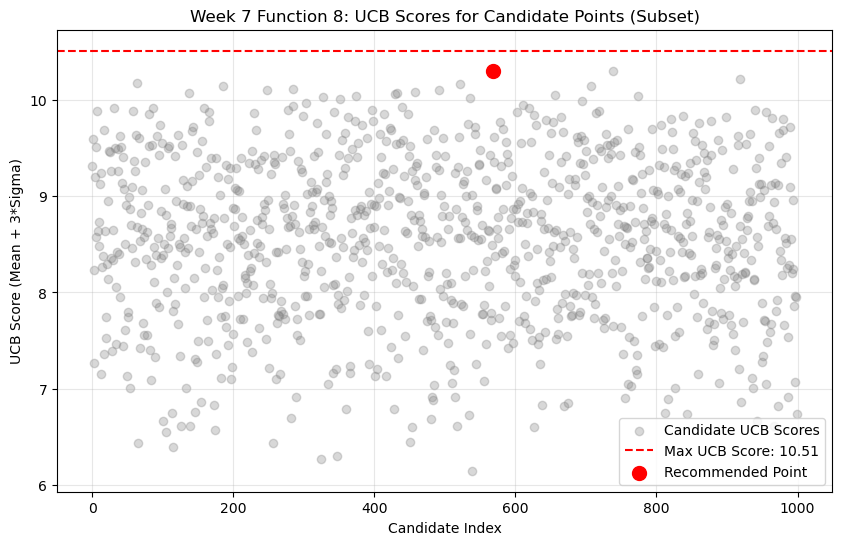

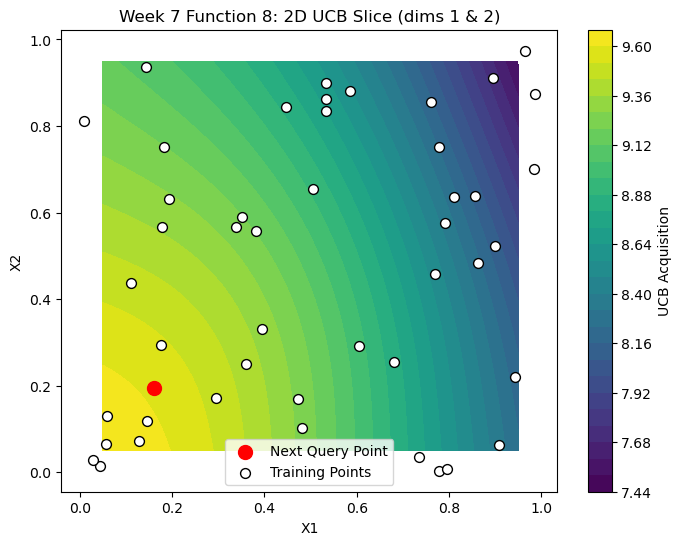

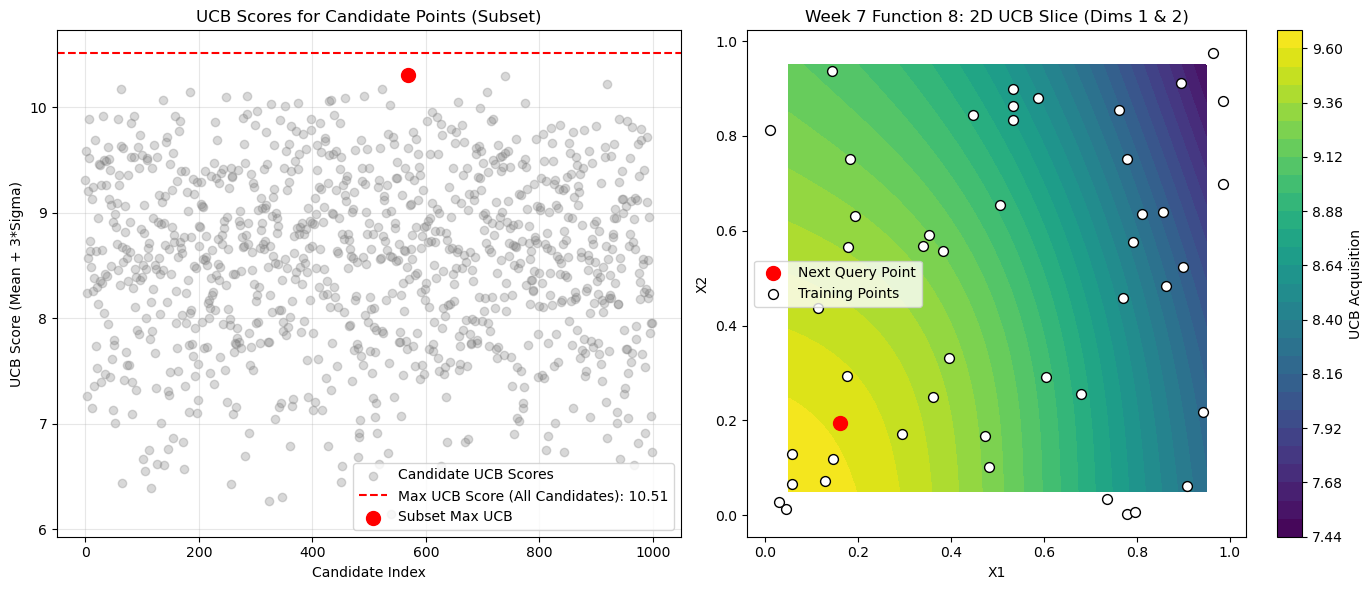

In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from pyDOE import lhs

# ==============================
# Step 1: Updated Training Data (Weeks 1–6)
# ==============================
X_train = np.array([[0.60499445, 0.29221502, 0.90845275, 0.35550624, 0.20166872,
        0.57533801, 0.31031095, 0.73428138],
       [0.17800696, 0.56622265, 0.99486184, 0.21032501, 0.32015266,
        0.70790879, 0.63538449, 0.10713163],
       [0.00907698, 0.81162615, 0.52052036, 0.07568668, 0.26511183,
        0.09165169, 0.59241515, 0.36732026],
       [0.50602816, 0.65373012, 0.36341078, 0.17798105, 0.09372830,
        0.19742533, 0.75582690, 0.29247234],
       [0.35990926, 0.24907568, 0.49599717, 0.70921498, 0.11498719,
        0.28920692, 0.55729515, 0.59388173],
       [0.77881834, 0.00341950, 0.33798313, 0.51952778, 0.82090699,
        0.53724669, 0.55134710, 0.66003209],
       [0.90864932, 0.06224970, 0.23825955, 0.76660355, 0.13233596,
        0.99024381, 0.68806782, 0.74249594],
       [0.58637144, 0.88073573, 0.74502075, 0.54603485, 0.00964888,
        0.74899176, 0.23090707, 0.09791562],
       [0.76113733, 0.85467239, 0.38212433, 0.33735198, 0.68970832,
        0.30985305, 0.63137968, 0.04195607],
       [0.98493320, 0.69950626, 0.99888550, 0.18014846, 0.58014315,
        0.23108719, 0.49082694, 0.31368272],
       [0.11207131, 0.43773566, 0.59659878, 0.59277563, 0.22698177,
        0.41010452, 0.92123758, 0.67475276],
       [0.79188751, 0.57619134, 0.69452836, 0.28342378, 0.13675546,
        0.27916186, 0.84276726, 0.62532792],
       [0.14355030, 0.93741452, 0.23232482, 0.00904349, 0.41457893,
        0.40932517, 0.55377852, 0.20584080],
       [0.76991655, 0.45875909, 0.55900044, 0.69460444, 0.50319902,
        0.72834638, 0.78425353, 0.66313109],
       [0.05644741, 0.06595555, 0.02292868, 0.03878647, 0.40393544,
        0.80105533, 0.48830701, 0.89308498],
       [0.86243745, 0.48273382, 0.28186940, 0.54410223, 0.88749026,
        0.38265469, 0.60190199, 0.47646169],
       [0.35151190, 0.59006494, 0.90943630, 0.67840835, 0.21282566,
        0.08846038, 0.41015300, 0.19572429],
       [0.73590364, 0.03461189, 0.72803027, 0.14742652, 0.29574314,
        0.44511731, 0.97517969, 0.37433978],
       [0.68029397, 0.25510465, 0.86218799, 0.13439582, 0.32632920,
        0.28790687, 0.43501048, 0.36420013],
       [0.04432925, 0.01358149, 0.25819824, 0.57764416, 0.05127992,
        0.15856307, 0.59103012, 0.07795293],
       [0.77834548, 0.75114565, 0.31414221, 0.90298577, 0.33538166,
        0.38632267, 0.74897249, 0.98875510],
       [0.89888711, 0.52364170, 0.87678325, 0.21869645, 0.90026089,
        0.28276624, 0.91107791, 0.47239822],
       [0.14512029, 0.11932754, 0.42088822, 0.38760861, 0.15542283,
        0.87517163, 0.51055967, 0.72861058],
       [0.33895442, 0.56693202, 0.37675110, 0.09891573, 0.65945169,
        0.24554809, 0.76248278, 0.73215347],
       [0.17615002, 0.29396143, 0.97567997, 0.79393631, 0.92340076,
        0.03084229, 0.80325452, 0.59589758],
       [0.02894663, 0.02827906, 0.48137155, 0.61317460, 0.67266045,
        0.02211341, 0.60148330, 0.52488505],
       [0.19263987, 0.63067728, 0.41679584, 0.49052929, 0.79608602,
        0.65456706, 0.27624119, 0.29551759],
       [0.94318502, 0.21885062, 0.72118408, 0.42459707, 0.98690200,
        0.53518298, 0.71474318, 0.96009372],
       [0.53272140, 0.83369260, 0.07139900, 0.11681148, 0.73069311,
        0.93737559, 0.86650798, 0.12790200],
       [0.44709584, 0.84395253, 0.72954612, 0.63915138, 0.40928714,
        0.13264569, 0.03590888, 0.44683847],
       [0.38222497, 0.55713584, 0.85310163, 0.33379569, 0.26572127,
        0.48087292, 0.23764706, 0.76863196],
       [0.53281953, 0.86230848, 0.53826712, 0.04944293, 0.71970119,
        0.90670590, 0.10823094, 0.52534791],
       [0.39486519, 0.33180167, 0.74075430, 0.69786172, 0.73740444,
        0.78377681, 0.25449546, 0.87114551],
       [0.98594539, 0.87305363, 0.07039262, 0.05358729, 0.73415296,
        0.52025852, 0.81104004, 0.10336036],
       [0.96457339, 0.97397979, 0.66375335, 0.66221599, 0.67312167,
        0.90523762, 0.45887462, 0.56091750],
       [0.47207071, 0.16820264, 0.08642757, 0.45265551, 0.48061922,
        0.62243949, 0.92897446, 0.11253627],
       [0.85600695, 0.63889370, 0.32619202, 0.66850311, 0.24029837,
        0.21029889, 0.16754636, 0.96358986],
       [0.81003174, 0.63504604, 0.26954758, 0.86960534, 0.66192159,
        0.25225873, 0.76567003, 0.89054867],
       [0.79625252, 0.00703653, 0.35569738, 0.48756605, 0.74051962,
        0.70665010, 0.99291449, 0.38173437],
       [0.48124533, 0.10246072, 0.21948594, 0.67732237, 0.24750919,
        0.24434086, 0.16382453, 0.71596164],
       [0.895434, 0.912022, 0.098160, 0.036667, 0.445138, 0.679791, 0.229544, 0.761742],
       [0.533209, 0.898485, 0.699395, 0.112874, 0.946419, 0.108092, 0.263289, 0.345445],
       [0.294680, 0.171230, 0.131225, 0.039384, 0.977541, 0.183968, 0.045086, 0.037349],
       [0.182500, 0.751289, 0.096803, 0.093917, 0.932979, 0.266073, 0.082636, 0.887906],
       [0.058026, 0.129966, 0.113848, 0.912375, 0.765246, 0.849704, 0.253476, 0.072370],
       [0.127331, 0.071329, 0.181538, 0.131744, 0.911727, 0.835220, 0.073672, 0.737489]])  

y_train = np.array([7.3987211 , 7.00522736, 8.45948162, 8.28400781, 8.60611679,
                    8.54174792, 7.32743458, 7.29987205, 7.95787474, 5.59219339,
                    7.85454099, 6.79198578, 8.97655402, 7.37908290, 9.59848200,
                    8.15998319, 7.13162397, 6.76796253, 7.43374407, 9.01307515,
                    7.31089382, 5.84106731, 9.14163949, 8.81755844, 6.45194313,
                    8.83074505, 9.34427428, 6.88784639, 8.04221254, 7.69236805,
                    7.92375877, 8.42175924, 8.27806240, 7.11345716, 6.40258841,
                    8.47293632, 7.97768459, 7.46087219, 7.43659353, 9.18300525,
                    8.0383561825836, 7.911617829373, 9.7162173430324, 9.5189864611379, 9.257621188839,
                    9.8315933694244])

# -----------------------------
# Fit Gaussian Process (Matern 5/2)
# -----------------------------
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=3.83, nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5, alpha=1e-6, normalize_y=True)
gp.fit(X_train, y_train)

# -----------------------------
# Upper Confidence Bound (UCB) acquisition function reduce kappa from 4.0 to 3.0
# -----------------------------
def ucb_acquisition(gp_model, X, kappa=3.0):
    mean, sigma = gp_model.predict(X, return_std=True)
    return mean + kappa * sigma

# -----------------------------
# Generate boundary-safe candidate points (8D)
# -----------------------------
n_candidates = 500_000  # You can still generate 500,000 candidates
X_candidates = 0.05 + 0.9 * lhs(8, samples=n_candidates)

# -----------------------------
# Evaluate candidates and select next query
# -----------------------------
ucb_values = ucb_acquisition(gp, X_candidates, kappa=3.0)  # Adjusted kappa for more exploitation
next_idx = np.argmax(ucb_values)
next_query = X_candidates[next_idx]

print("Week 7 Function 8: Next query point (8D):")
print(next_query)

# -----------------------------
# Week 7 UCB plot (Subset for clarity)
# -----------------------------
plt.figure(figsize=(10, 6))
subset = 1000  # Plot only first 1000 candidates for clarity
plt.scatter(range(subset), ucb_values[:subset], alpha=0.3, color='gray', label='Candidate UCB Scores')
plt.axhline(y=np.max(ucb_values), color='r', linestyle='--', label=f'Max UCB Score: {np.max(ucb_values):.2f}')
plt.scatter([np.argmax(ucb_values[:subset])], [np.max(ucb_values[:subset])], color='red', s=100, label='Recommended Point')
plt.title('Week 7 Function 8: UCB Scores for Candidate Points (Subset)')
plt.xlabel('Candidate Index')
plt.ylabel('UCB Score (Mean + 3*Sigma)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# Optional 2D slice plot (X1 vs X2) for Week 7
# -----------------------------
X_fixed = np.mean(X_train[:, 2:], axis=0)  # Fix other dimensions at mean
grid_size = 50  # Use a smaller grid size for better resolution around promising areas
x1 = np.linspace(0.05, 0.95, grid_size)
x2 = np.linspace(0.05, 0.95, grid_size)
X1, X2 = np.meshgrid(x1, x2)

X_grid = np.zeros((grid_size**2, 8))
X_grid[:, 0] = X1.ravel()
X_grid[:, 1] = X2.ravel()
X_grid[:, 2:] = X_fixed
acq_grid = ucb_acquisition(gp, X_grid, kappa=3.0).reshape(grid_size, grid_size)

plt.figure(figsize=(8, 6))
contour = plt.contourf(X1, X2, acq_grid, levels=30, cmap='viridis')
plt.colorbar(contour, label='UCB Acquisition')
plt.scatter(next_query[0], next_query[1], color='red', s=100, label='Next Query Point')
plt.scatter(X_train[:, 0], X_train[:, 1], color='white', edgecolor='black', s=50, label='Training Points')
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Week 7 Function 8: 2D UCB Slice (dims 1 & 2)')
plt.legend()
plt.show()

# -----------------------------
# Week 7 Combined Visualisation for Function 8
# -----------------------------
import matplotlib.gridspec as gridspec

# Use a figure with 2 subplots
plt.figure(figsize=(14, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1])

# --------- Plot 1: Subset of UCB scores ---------
ax0 = plt.subplot(gs[0])
subset = 1000  # Plot first 1000 candidates for clarity
ax0.scatter(range(subset), ucb_values[:subset], alpha=0.3, color='gray', label='Candidate UCB Scores')
ax0.axhline(y=np.max(ucb_values), color='r', linestyle='--', label=f'Max UCB Score (All Candidates): {np.max(ucb_values):.2f}')
ax0.scatter([np.argmax(ucb_values[:subset])], [np.max(ucb_values[:subset])], color='red', s=100, label='Subset Max UCB')
ax0.set_title('UCB Scores for Candidate Points (Subset)')
ax0.set_xlabel('Candidate Index')
ax0.set_ylabel('UCB Score (Mean + 3*Sigma)')
ax0.legend()
ax0.grid(True, alpha=0.3)

# --------- Plot 2: 2D UCB Slice (X1 vs X2) ---------
ax1 = plt.subplot(gs[1])

grid_size = 50  # Use a smaller grid size for better resolution
x1 = np.linspace(0.05, 0.95, grid_size)
x2 = np.linspace(0.05, 0.95, grid_size)
X1, X2 = np.meshgrid(x1, x2)

X_grid = np.zeros((grid_size**2, 8))
X_grid[:, 0] = X1.ravel()
X_grid[:, 1] = X2.ravel()
X_grid[:, 2:] = X_fixed

acq_grid = ucb_acquisition(gp, X_grid, kappa=3.0).reshape(grid_size, grid_size)

contour = ax1.contourf(X1, X2, acq_grid, levels=30, cmap='viridis')
plt.colorbar(contour, ax=ax1, label='UCB Acquisition')
ax1.scatter(next_query[0], next_query[1], color='red', s=100, label='Next Query Point')
ax1.scatter(X_train[:, 0], X_train[:, 1], color='white', edgecolor='black', s=50, label='Training Points')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_title('Week 7 Function 8: 2D UCB Slice (Dims 1 & 2)')
ax1.legend()

plt.tight_layout()
plt.show()